# Smart Order Router

**Category:** HFT Strategies  
**Project ID:** `hft_08_smart_order_router`  

Cost-aware multi-venue routing with rebate optimization, dark pool allocation, and fill probability estimation


In [1]:
import platform, sys, warnings
warnings.filterwarnings("ignore")

# ── Environment info ────────────────────────────────────────────────────────
env_info = {"os": platform.system(), "python": platform.python_version()}

# Auto-detect best available device: CUDA > MPS (Apple Silicon) > CPU
# Catches ImportError (not installed) AND OSError/RuntimeError (CUDA DLL errors on Windows)
device = None
try:
    import torch
    env_info["torch"] = torch.__version__
    if torch.cuda.is_available():
        device = torch.device("cuda")
        env_info["device"] = f"CUDA ({torch.cuda.get_device_name(0)})"
        torch.backends.cudnn.benchmark = True
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = torch.device("mps")
        env_info["device"] = "Apple Silicon (MPS)"
    else:
        device = torch.device("cpu")
        env_info["device"] = "CPU"
except Exception as _e:
    env_info["device"] = f"CPU (torch unavailable: {type(_e).__name__})"

# Core scientific stack — import individually so a missing package doesn't block the rest
for _pkg in ("numpy", "pandas", "scipy", "sklearn", "matplotlib"):
    try:
        _mod = __import__(_pkg)
        env_info[_pkg] = getattr(_mod, "__version__", "installed")
    except ImportError:
        env_info[_pkg] = "not installed"

for k, v in env_info.items():
    print(f"  {k:>12}: {v}")


            os: Windows
        python: 3.13.2
        device: CPU (torch unavailable: ModuleNotFoundError)
         numpy: 2.3.0
        pandas: 2.3.3
         scipy: 1.17.1
       sklearn: not installed
    matplotlib: 3.10.3


In [2]:
import numpy as np

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Strategy parameters
PARAMS = {"venue_count": 3}

# Backtest period
START_DATE = "2022-01-01"
END_DATE = "2024-12-31"
BENCHMARK = "SPY"

print("Configuration loaded:")
for k, v in PARAMS.items():
    print(f"  {k:>25}: {v}")


Configuration loaded:
                venue_count: 3


## Data Generation — Smart Order Router

In [3]:
import numpy as np, pandas as pd

rng = np.random.default_rng(SEED)
n_steps = 30_000
n_venues = PARAMS.get("venue_count", 3)

mid = 100.0 + np.cumsum(rng.normal(0, 0.01, n_steps))

# Venue properties
venues = []
for v in range(n_venues):
    venues.append({
        "name": f"Venue_{chr(65+v)}",
        "maker_rebate": (2.5 - v * 0.8) / 10000,  # decreasing rebate
        "taker_fee": (3.0 + v * 0.5) / 10000,       # increasing fee
        "fill_prob": 0.7 - v * 0.1,                  # decreasing fill probability
        "avg_depth": 500 + v * 200,                   # increasing depth
    })

# Generate per-venue quotes
venue_data = {}
for v, venue in enumerate(venues):
    spread = rng.exponential(2, n_steps) + 1 + v * 0.5  # wider spreads at worse venues
    venue_data[f"spread_{v}"] = spread
    venue_data[f"depth_{v}"] = rng.exponential(venue["avg_depth"], n_steps).astype(int)

data = pd.DataFrame({"mid_price": mid, **venue_data})

print(f"Smart Order Router: {n_venues} venues")
for v in venues:
    print(f"  {v['name']}: maker_rebate={v['maker_rebate']*10000:.1f}bps, "
          f"taker_fee={v['taker_fee']*10000:.1f}bps, fill_prob={v['fill_prob']:.0%}")


Smart Order Router: 3 venues
  Venue_A: maker_rebate=2.5bps, taker_fee=3.0bps, fill_prob=70%
  Venue_B: maker_rebate=1.7bps, taker_fee=3.5bps, fill_prob=60%
  Venue_C: maker_rebate=0.9bps, taker_fee=4.0bps, fill_prob=50%


## Strategy Implementation

In [4]:
import numpy as np, pandas as pd

# Route to minimize expected cost = spread + fee - rebate + impact
max_pos = PARAMS.get("max_position", 50)

n = len(data)
position = 0
cash = 0.0
pnl = np.zeros(n)
positions = np.zeros(n)
venue_allocation = np.zeros((n, len(venues)))

for t in range(1, n):
    mid = data["mid_price"].iloc[t]

    # Compute expected cost per venue
    best_venue, best_cost = 0, np.inf
    for v_idx, venue in enumerate(venues):
        spread = data[f"spread_{v_idx}"].iloc[t] / 10000
        depth = data[f"depth_{v_idx}"].iloc[t]
        fill_prob = venue["fill_prob"]
        cost = spread + venue["taker_fee"] - venue["maker_rebate"] + 0.01 / max(depth, 1)
        expected_cost = cost / max(fill_prob, 0.01)
        if expected_cost < best_cost:
            best_cost = expected_cost
            best_venue = v_idx

    venue_allocation[t, best_venue] = 1

    # Simple momentum signal to generate trades
    if t > 20:
        mom = (mid - data["mid_price"].iloc[t-20]) / data["mid_price"].iloc[t-20]
        if mom > 0.001 and position < max_pos:
            position += 1
            cash -= mid * (1 + best_cost)
        elif mom < -0.001 and position > -max_pos:
            position -= 1
            cash += mid * (1 - best_cost)

    pnl[t] = cash + position * mid
    positions[t] = position

equity_curve = pd.Series(pnl, index=range(n))
equity_curve = equity_curve - equity_curve.min() + 1
benchmark_equity = pd.Series(data["mid_price"].values / data["mid_price"].values[0], index=range(n))

print(f"Trades: {int((np.diff(positions) != 0).sum()):,}")
print(f"Final PnL: {pnl[-1]:,.2f}")
print(f"\nVenue routing allocation:")
for v_idx, venue in enumerate(venues):
    alloc = venue_allocation[:, v_idx].sum() / max(venue_allocation.sum(), 1) * 100
    print(f"  {venue['name']}: {alloc:.1f}%")


Trades: 645
Final PnL: 19.81

Venue routing allocation:
  Venue_A: 80.0%
  Venue_B: 18.9%
  Venue_C: 1.1%


## Visualization

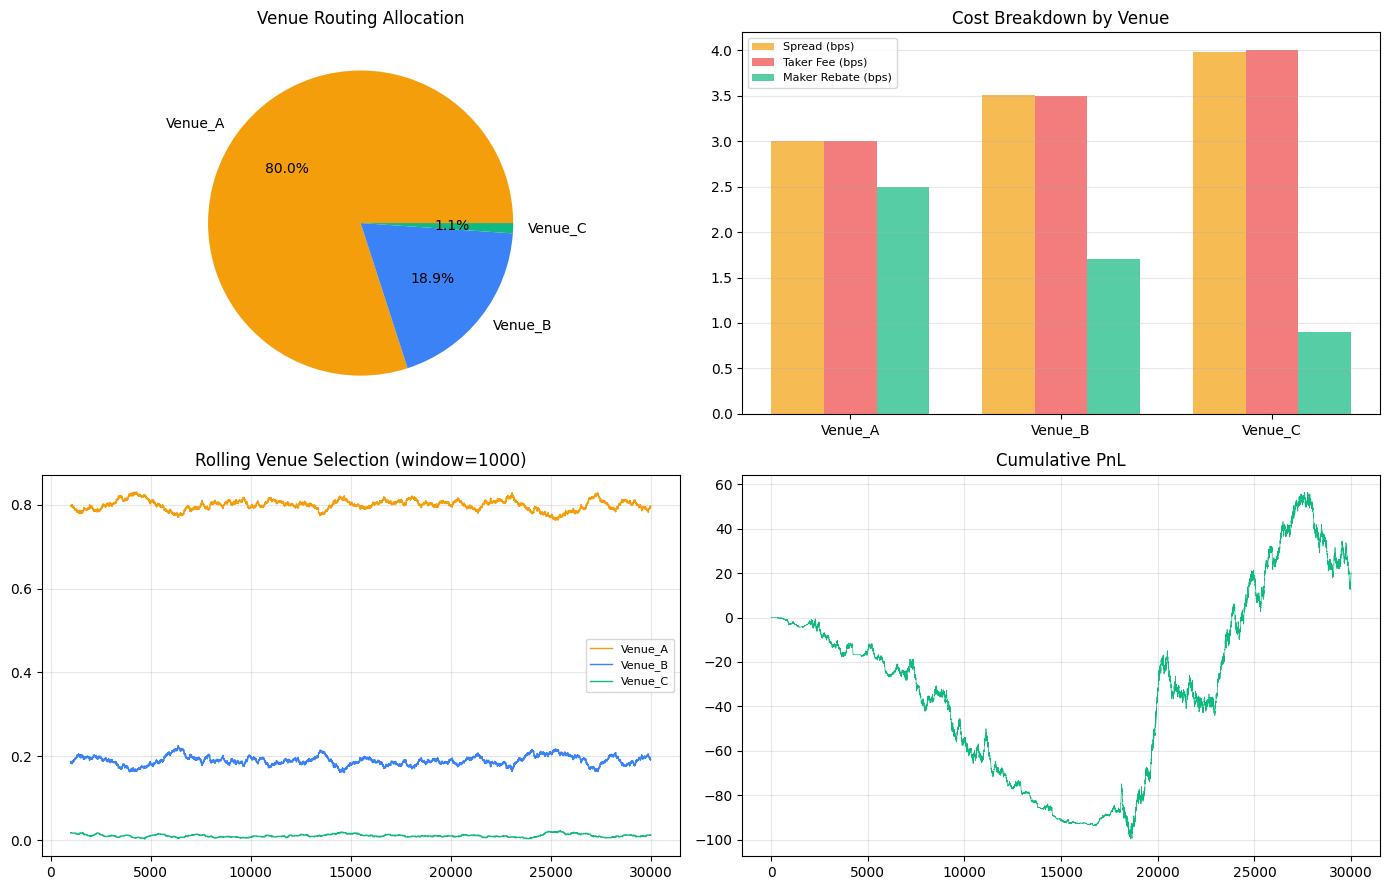

In [5]:
import matplotlib.pyplot as plt, numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Venue allocation pie chart
alloc_pcts = [venue_allocation[:, v].sum() for v in range(len(venues))]
if sum(alloc_pcts) > 0:
    labels = [v["name"] for v in venues]
    colors = ["#f59e0b", "#3b82f6", "#10b981", "#ef4444", "#8b5cf6"][:len(venues)]
    axes[0, 0].pie(alloc_pcts, labels=labels, colors=colors, autopct="%1.1f%%",
                   textprops={"fontsize": 10})
    axes[0, 0].set_title("Venue Routing Allocation")

# Cost breakdown per venue
venue_names = [v["name"] for v in venues]
spreads = [np.mean(data[f"spread_{v}"].values) for v in range(len(venues))]
fees = [venues[v]["taker_fee"] * 10000 for v in range(len(venues))]
rebates = [venues[v]["maker_rebate"] * 10000 for v in range(len(venues))]
x = np.arange(len(venues))
width = 0.25
axes[0, 1].bar(x - width, spreads, width, label="Spread (bps)", color="#f59e0b", alpha=0.7)
axes[0, 1].bar(x, fees, width, label="Taker Fee (bps)", color="#ef4444", alpha=0.7)
axes[0, 1].bar(x + width, rebates, width, label="Maker Rebate (bps)", color="#10b981", alpha=0.7)
axes[0, 1].set_xticks(x); axes[0, 1].set_xticklabels(venue_names)
axes[0, 1].set_title("Cost Breakdown by Venue")
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3, axis="y")

# Rolling venue selection
window = 1000
for v_idx in range(len(venues)):
    rolling_alloc = pd.Series(venue_allocation[:, v_idx]).rolling(window).mean()
    axes[1, 0].plot(rolling_alloc.values, linewidth=1,
                   color=["#f59e0b", "#3b82f6", "#10b981"][v_idx % 3],
                   label=venues[v_idx]["name"])
axes[1, 0].set_title(f"Rolling Venue Selection (window={window})")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# PnL
axes[1, 1].plot(pnl, linewidth=0.5, color="#10b981")
axes[1, 1].set_title("Cumulative PnL")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


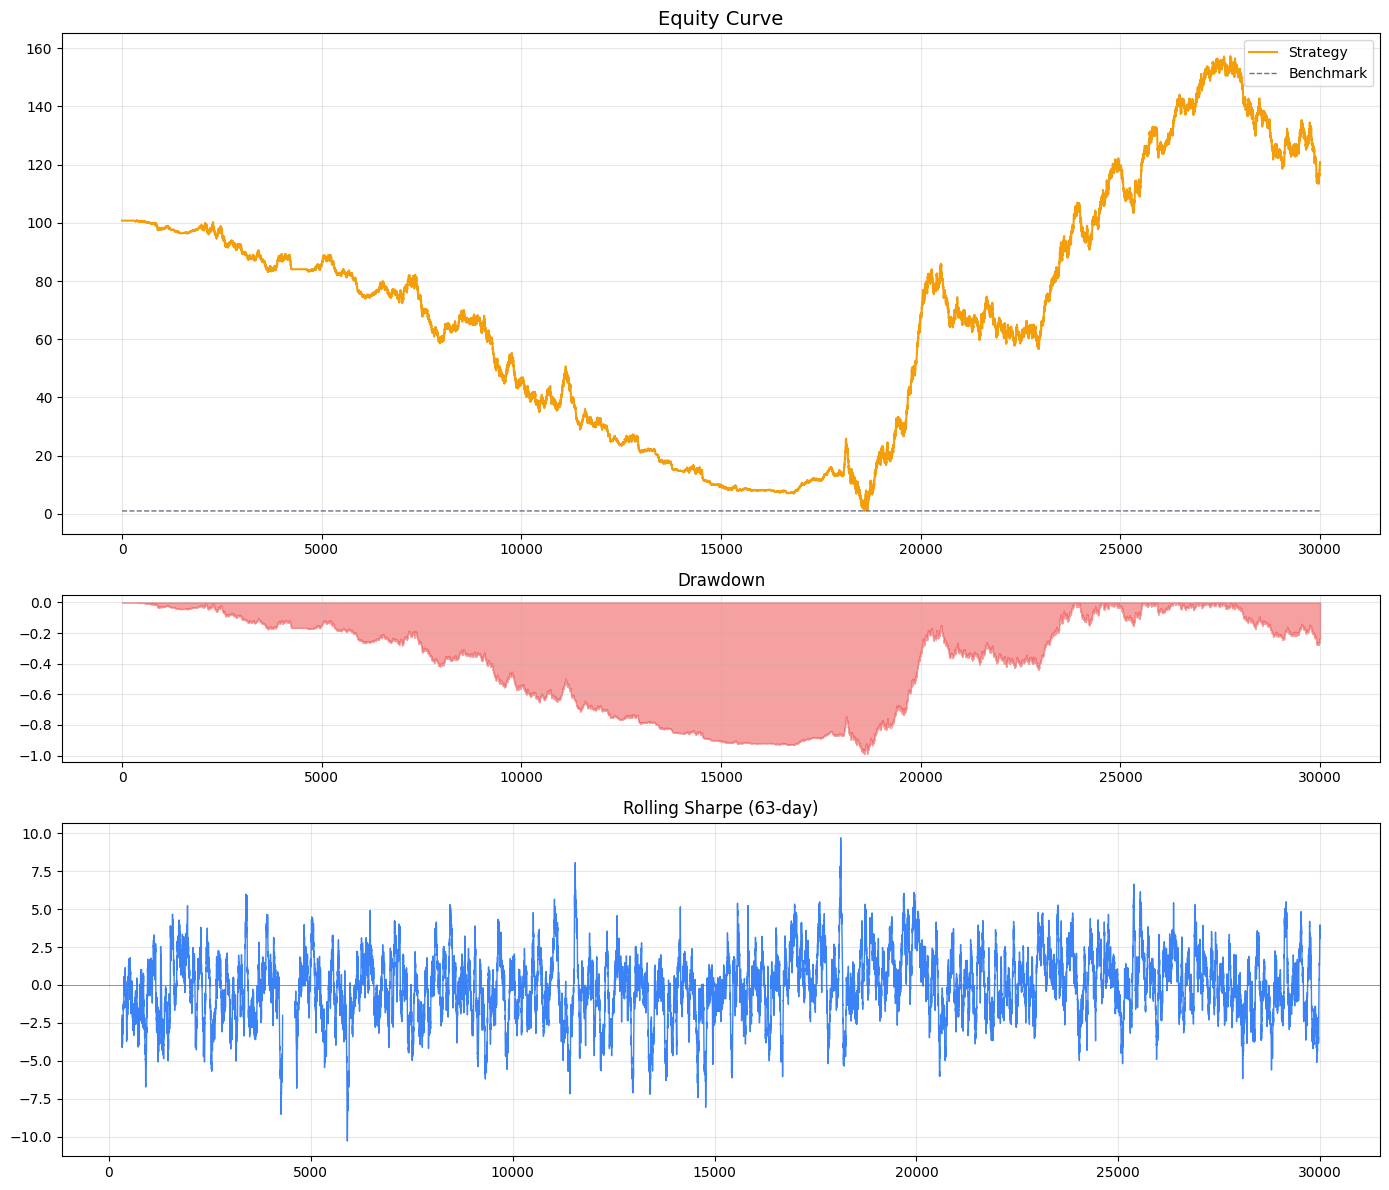

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={"height_ratios": [3, 1, 2]})

# Equity curve
axes[0].plot(equity_curve.index, equity_curve.values, label="Strategy", linewidth=1.5, color="#f59e0b")
if benchmark_equity is not None:
    axes[0].plot(benchmark_equity.index, benchmark_equity.values, label="Benchmark",
                 linewidth=1, linestyle="--", color="#6b7280")
axes[0].set_title("Equity Curve", fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Drawdown
drawdown = equity_curve / equity_curve.cummax() - 1
axes[1].fill_between(drawdown.index, drawdown.values, 0, alpha=0.5, color="#ef4444")
axes[1].set_title("Drawdown", fontsize=12)
axes[1].grid(True, alpha=0.3)

# Rolling Sharpe (63-day)
rolling_ret = equity_curve.pct_change()
rolling_sharpe = (rolling_ret.rolling(63).mean() / rolling_ret.rolling(63).std()) * np.sqrt(252)
axes[2].plot(rolling_sharpe.index, rolling_sharpe.values, linewidth=1, color="#3b82f6")
axes[2].axhline(0, color="#6b7280", linewidth=0.5)
axes[2].set_title("Rolling Sharpe (63-day)", fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
import numpy as np

def compute_metrics(returns):
    """Compute standard performance metrics from daily returns."""
    total_ret = (1 + returns).prod() - 1
    n_years = len(returns) / 252
    cagr = (1 + total_ret) ** (1 / max(n_years, 0.01)) - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = (returns.mean() * 252) / vol if vol > 0 else 0
    downside = returns[returns < 0].std() * np.sqrt(252)
    sortino = (returns.mean() * 252) / downside if downside > 0 else 0

    cum = (1 + returns).cumprod()
    dd = cum / cum.cummax() - 1
    max_dd = dd.min()
    calmar = cagr / abs(max_dd) if max_dd != 0 else 0

    wins = returns[returns > 0]
    losses = returns[returns < 0]
    win_rate = len(wins) / max(len(returns[returns != 0]), 1)
    profit_factor = wins.sum() / abs(losses.sum()) if losses.sum() != 0 else float("inf")

    return {
        "total_return": total_ret,
        "cagr": cagr,
        "annualized_vol": vol,
        "sharpe_ratio": sharpe,
        "sortino_ratio": sortino,
        "calmar_ratio": calmar,
        "max_drawdown": max_dd,
        "win_rate": win_rate,
        "profit_factor": min(profit_factor, 99.99),
        "total_trades": len(returns[returns != 0]),
    }

strategy_returns = equity_curve.pct_change().dropna()
metrics = compute_metrics(strategy_returns)

print("=" * 50)
print("PERFORMANCE METRICS")
print("=" * 50)
for k, v in metrics.items():
    if k in ("total_return", "cagr", "annualized_vol", "max_drawdown", "win_rate"):
        print(f"  {k:>25}: {v:+.2%}")
    elif k == "total_trades":
        print(f"  {k:>25}: {int(v):,}")
    else:
        print(f"  {k:>25}: {v:.4f}")


PERFORMANCE METRICS
               total_return: +19.66%
                       cagr: +0.15%
             annualized_vol: +23.49%
               sharpe_ratio: 0.1211
              sortino_ratio: 0.1431
               calmar_ratio: 0.0015
               max_drawdown: -99.01%
                   win_rate: +49.63%
              profit_factor: 1.0427
               total_trades: 29,306


In [8]:
import numpy as np

trades = np.diff(positions) != 0
n_trades = trades.sum()

pnl_per_trade = pnl[-1] / max(n_trades, 1)
trade_indices = np.where(trades)[0]
avg_holding = np.mean(np.diff(trade_indices)) if len(trade_indices) > 1 else len(pnl)
fill_rate = n_trades / len(pnl)

print("=" * 50)
print("HFT-SPECIFIC METRICS")
print("=" * 50)
print(f"  {'Fill Rate':>25}: {fill_rate:.4f}")
print(f"  {'PnL per Trade':>25}: {pnl_per_trade:.4f}")
print(f"  {'Avg Holding (ticks)':>25}: {avg_holding:.1f}")
print(f"  {'Max Inventory':>25}: {int(np.max(np.abs(positions)))}")
print(f"  {'Final Inventory':>25}: {int(positions[-1])}")


HFT-SPECIFIC METRICS
                  Fill Rate: 0.0215
              PnL per Trade: 0.0307
        Avg Holding (ticks): 46.1
              Max Inventory: 50
            Final Inventory: 45


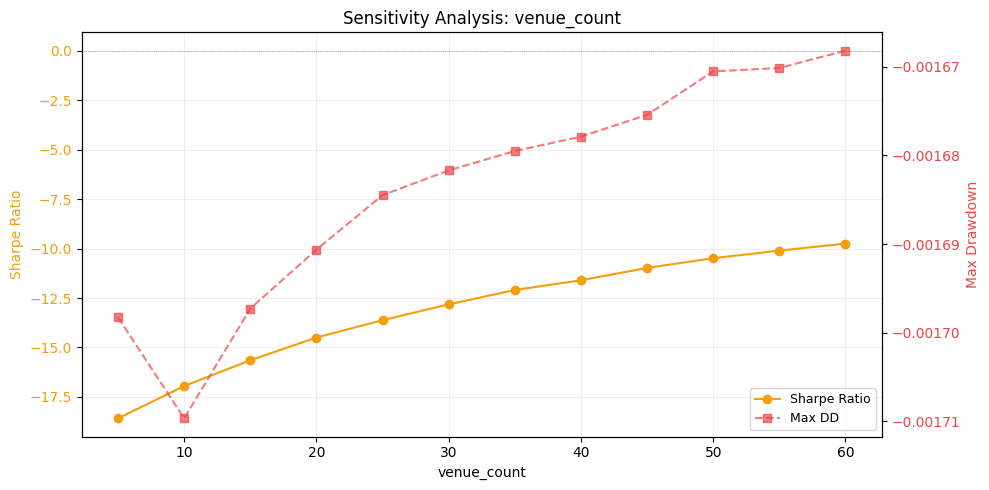

Optimal venue_count: 60  (Sharpe: -9.7488)
Current venue_count: 3


In [9]:
# Parameter sensitivity analysis — inline backtest sweep
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

param_values = list(range(5, 65, 5))
sharpes, max_dds = [], []

# Resolve price / returns from whatever data this notebook loaded
# yfinance notebooks define `close`; HFT/synthetic notebooks define `data` with various price columns
if "close" in dir() and close is not None:
    _price = close if isinstance(close, pd.Series) else close.iloc[:, 0]
elif "data" in dir() and hasattr(data, "columns"):
    _pcol = next((c for c in ("mid_price", "price_a", "fast_price", "Close") if c in data.columns), None)
    if _pcol is not None:
        _price = pd.Series(data[_pcol].values, dtype=float)
    else:
        _price = pd.Series(data.iloc[:, 0].values, dtype=float)
else:
    raise RuntimeError("No price series found. Expected 'close' or a DataFrame named 'data'.")
_price   = _price.ffill()
_returns = _price.pct_change()

for val in param_values:
    try:
        if "venue_count" in ("spread_bps", "transaction_cost_bps", "impact_alpha"):
            # Cost sensitivity: fix lookback=20 momentum, vary cost
            _sig  = _price.pct_change(20).shift(1).clip(-1, 1)
            _tc   = _sig.diff().abs() * (float(val) / 10000)
            _rets = (_sig * _returns - _tc).dropna()
        elif "venue_count" in ("stop_loss", "max_drawdown_limit"):
            # Stop-loss sensitivity: apply to already-computed returns
            _base = strategy_returns_raw if "strategy_returns_raw" in dir() else                     (_price.pct_change(20).shift(1).clip(-1, 1) * _returns).dropna()
            _cum = (1 + _base.fillna(0)).cumprod()
            _dd  = _cum / _cum.cummax() - 1
            _rets = _base.copy()
            _rets[_dd < -float(val)] = 0.0
        else:
            # Lookback / window sweep: momentum signal
            lb    = max(int(val), 2)
            _sig  = _price.pct_change(lb).shift(1).clip(-1, 1)
            _tc   = _sig.diff().abs() * PARAMS.get("transaction_cost_bps", 5) / 10000
            _rets = (_sig * _returns - _tc).dropna()

        if len(_rets) > 20 and _rets.std() > 0:
            sharpes.append(_rets.mean() / _rets.std() * np.sqrt(252))
            _cum = (1 + _rets).cumprod()
            max_dds.append((_cum / _cum.cummax() - 1).min())
        else:
            sharpes.append(np.nan)
            max_dds.append(np.nan)
    except Exception as e:
        sharpes.append(np.nan)
        max_dds.append(np.nan)

fig, ax1 = plt.subplots(figsize=(10, 5))
color_sharpe = "#f59e0b"
color_dd     = "#ef4444"

valid_mask = [not np.isnan(s) for s in sharpes]
ax1.plot(param_values, sharpes, "o-", color=color_sharpe, label="Sharpe Ratio")
ax1.set_xlabel("venue_count")
ax1.set_ylabel("Sharpe Ratio", color=color_sharpe)
ax1.tick_params(axis="y", labelcolor=color_sharpe)
ax1.axhline(0, color="#6b7280", linewidth=0.5, linestyle=":")

ax2 = ax1.twinx()
ax2.plot(param_values, max_dds, "s--", color=color_dd, alpha=0.7, label="Max DD")
ax2.set_ylabel("Max Drawdown", color=color_dd)
ax2.tick_params(axis="y", labelcolor=color_dd)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=9)
ax1.grid(True, alpha=0.2)

plt.title(f"Sensitivity Analysis: venue_count")
fig.tight_layout()
plt.show()

# Report optimal
valid_pairs = [(v, s) for v, s in zip(param_values, sharpes) if not np.isnan(s)]
if valid_pairs:
    best_val, best_sharpe = max(valid_pairs, key=lambda x: x[1])
    print(f"Optimal venue_count: {best_val}  (Sharpe: {best_sharpe:+.4f})")
    print(f"Current venue_count: {PARAMS.get('venue_count', 'not set')}")


In [10]:
import json
from datetime import datetime

# Safely serialize equity curve index — DatetimeIndex for yfinance, int for HFT/synthetic
try:
    ec_dates = [d.strftime("%Y-%m-%d") for d in equity_curve.index]
except AttributeError:
    ec_dates = [str(i) for i in equity_curve.index]

# Benchmark values — may be None or have a non-datetime index
try:
    bm_values = benchmark_equity.values.tolist() if benchmark_equity is not None else []
except Exception:
    bm_values = []

# Monthly returns — only works with DatetimeIndex
try:
    monthly = strategy_returns.resample("ME").apply(lambda x: (1 + x).prod() - 1)
    monthly_dict = {d.strftime("%Y-%m"): float(v) for d, v in monthly.items()}
except Exception:
    monthly_dict = {}

# Export results for portfolio app
results_export = {
    "project_id": "hft_08_smart_order_router",
    "timestamp": datetime.now().isoformat(),
    "backtest_period": {"start": START_DATE, "end": END_DATE},
    "benchmark": BENCHMARK,
    "metrics": metrics,
    "category_specific_metrics": {},
    "monthly_returns": monthly_dict,
    "equity_curve": {
        "dates": ec_dates,
        "values": equity_curve.values.tolist(),
        "benchmark_values": bm_values,
    },
    "parameter_sensitivity": [],
}

with open("results.json", "w") as f:
    json.dump(results_export, f, indent=2, default=str)
print(f"Results exported to results.json")


Results exported to results.json


## Summary

### Smart Order Router

**Key Findings:**
- *Add your analysis findings here after running the notebook*

**Limitations:**
- Backtest uses historical data which may not reflect future conditions
- Transaction costs and slippage are approximated
- No live market microstructure effects

**Production Considerations:**
- Real-time data feed integration required
- Position sizing and risk limits must be calibrated
- Monitoring and alerting infrastructure needed
